# run hopfield network

In [1]:
import modules.hopfield_network as hp

## memories:

In [2]:
img_ufsc, vetor_ufsc = hp.preprocessar_para_hopfield('dataset/ufsc.png', size=60, threshold=0.6, swap_colors=True)
img_github, vetor_github = hp.preprocessar_para_hopfield('dataset/github.png', size=60, threshold=0.60, swap_colors=True)
img_playstation, vetor_playstation = hp.preprocessar_para_hopfield('dataset/playstation.png', size=60, threshold=0.3, swap_colors=False)

In [3]:
print(len(vetor_ufsc))
print(vetor_ufsc)

3600
[1. 1. 1. ... 1. 1. 1.]


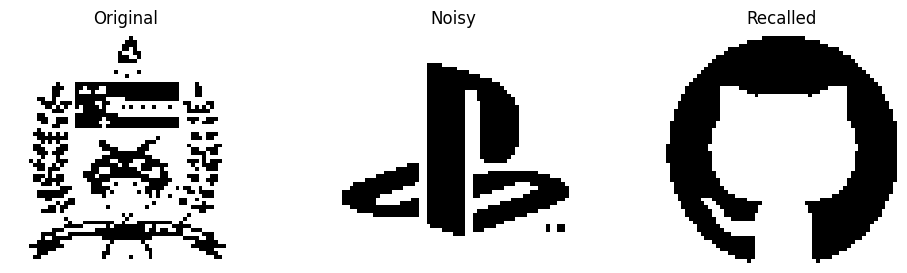

In [4]:
hp.vizualize([vetor_ufsc],[vetor_playstation],[vetor_github],len(vetor_ufsc), save=False)

In [5]:
memories = [vetor_ufsc, vetor_playstation, vetor_github]

## training the network:

In [6]:
weights = hp.train(len(vetor_ufsc), memories)

## perturbing the memories

In [7]:
noisies = hp.noisy_patterns(memories,len(memories), noise_level=0.45)

## remembering from noisies:

In [8]:
remembered = hp.retrieve_all_sync(noisies, len(vetor_ufsc), weights, len(memories))

## visualize recalling:

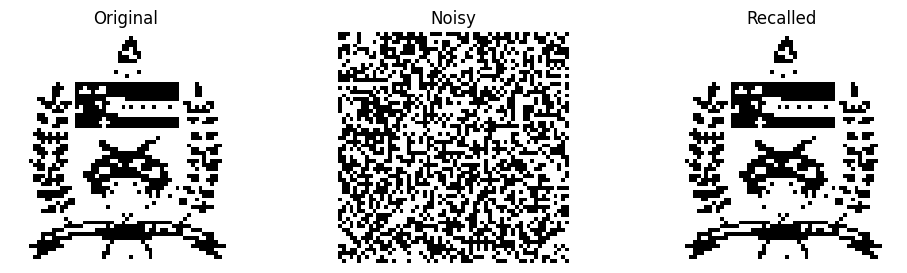

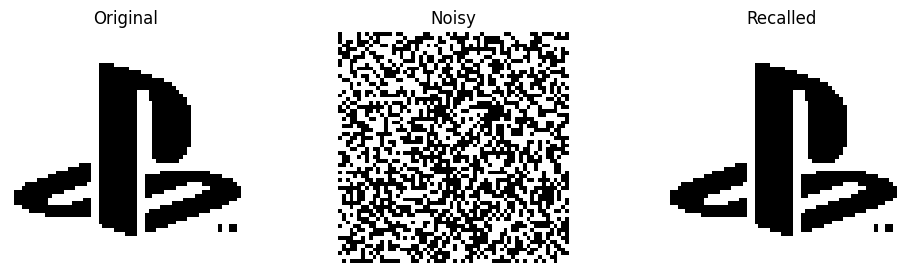

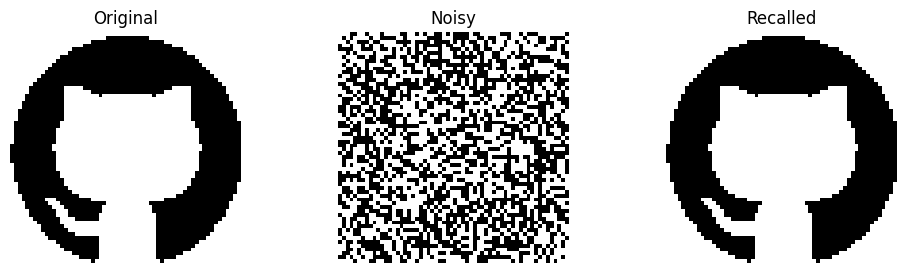

In [9]:
hp.vizualize(memories, noisies, remembered, len(vetor_ufsc), save=False)

## juntando tudo

In [10]:
def test_network(memory_list, weight_matrix, noise_level, synchronous=True):
    """
    Tests a trained Hopfield network by adding noise to stored patterns,
    retrieving them, and visualizing the results.

    The procedure is:

    1. Apply random noise to the stored memory patterns.
    2. Recover the patterns using synchronous or asynchronous dynamics.
    3. Display original, noisy, and retrieved patterns side by side.

    Parameters
    ----------
    memory_list : list of numpy.ndarray
        List of stored bipolar memory patterns.

        Each pattern must be a 1D vector containing values such as:
        {-1, +1}

    weight_matrix : numpy.ndarray
        Trained Hopfield weight matrix with shape:

            (N, N)

        where N is the number of neurons.

    noise_level : float
        Fraction of bits/pixels to corrupt in each stored pattern.

        Typical range:
        0.0 to 1.0

        Examples:
        - 0.10 = 10% noise
        - 0.30 = 30% noise
        - 0.50 = 50% noise

    synchronous : bool, optional
        Determines which update rule is used during retrieval.

        If True:
            Uses synchronous updates, where all neurons are updated
            simultaneously.

        If False:
            Uses asynchronous updates, where neurons are updated
            one at a time.

        Default is True.

    Returns
    -------
    None
        Displays the recovery results and returns nothing.

    Notes
    -----
    Internally, this function calls:

    - hp.noisy_patterns(...)
    - hp.retrieve_all_sync(...)
    - hp.retrieve_all_assync(...)
    - hp.vizualize(...)

    This function is useful for evaluating:

    - Memory robustness
    - Pattern recovery quality
    - Noise tolerance
    - Differences between synchronous and asynchronous dynamics

    Example
    -------
    test_network(memories, weights, noise_level=0.25)

    test_network(memories, weights, noise_level=0.25, synchronous=False)
    """
    noisies = hp.noisy_patterns(memory_list, len(memory_list), noise_level=noise_level)
    if synchronous:
        retrieved_patterns = hp.retrieve_all_sync(noisies, len(memory_list[0]), weight_matrix, len(memory_list))
    else:
        retrieved_patterns = hp.retrieve_all_assync(noisies, len(memory_list[0]), weight_matrix, len(memory_list))
    hp.vizualize(memory_list, noisies, retrieved_patterns, len(memory_list[0]), save=False)
    return None


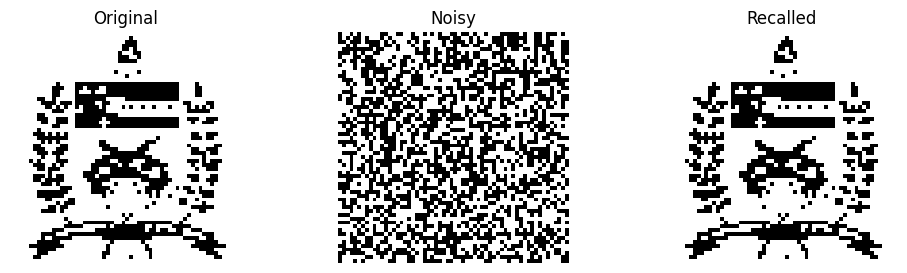

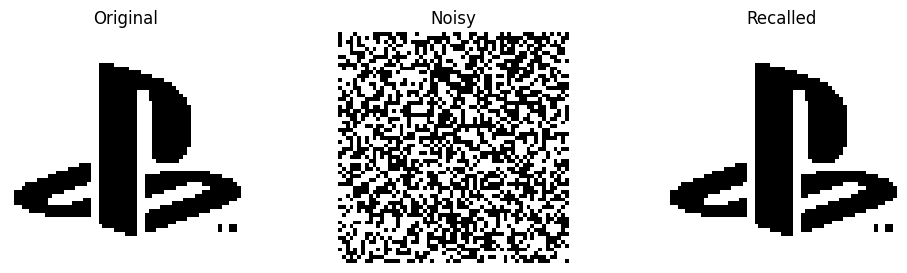

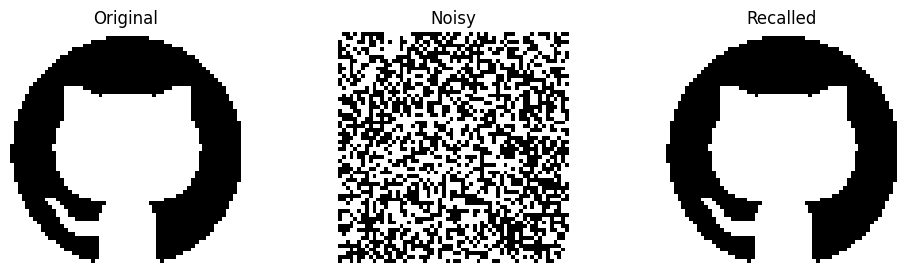

In [11]:
test_network(memories, weights, noise_level=0.45, synchronous=True)

## Visualizing weight matrix:

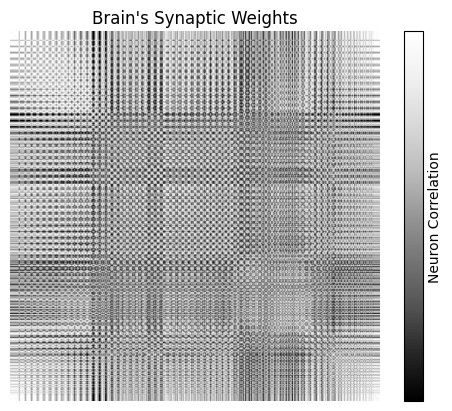

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Example matrix
matrix = weights

#plt.style.use('dark_background')
plt.imshow(matrix, cmap='Grays_r')  # colormap can be changed
cbar = plt.colorbar()
cbar.set_label("Neuron Correlation")  # Label for colorbar
cbar.set_ticks([])  # Show colorbar ticks
plt.axis('off')  # Hide axes
plt.title("Brain's Synaptic Weights")  # Title for the heatmap
plt.show()

In [13]:
def see_synapses(weights_matrix):
    """
    Visualizes the synaptic weights of a Hopfield network as a heatmap.

    Parameters
    ----------
    weights_matrix : numpy.ndarray
        The weight matrix of the Hopfield network, typically of shape (N, N),
        where N is the number of neurons.

    Returns
    -------
    None
        Displays the heatmap of synaptic weights and returns nothing.

    Notes
    -----
    This function uses matplotlib to create a heatmap representation of the
    synaptic weights. The color intensity indicates the strength of the weights,
    with darker colors representing stronger connections.

    Example
    -------
    see_synapses(weights)
    """
    plt.style.use('dark_background')
    plt.imshow(weights_matrix, cmap='magma_r')  # colormap can be changed
    cbar = plt.colorbar()
    cbar.set_label("Neuron Correlation", fontsize=18)  # Label for colorbar
    cbar.set_ticks([])  # Show colorbar ticks
    plt.axis('off')  # Hide axes
    plt.title("Brain's Synaptic Weights", fontsize=20)  # Title for the heatmap
    plt.show()
    return None

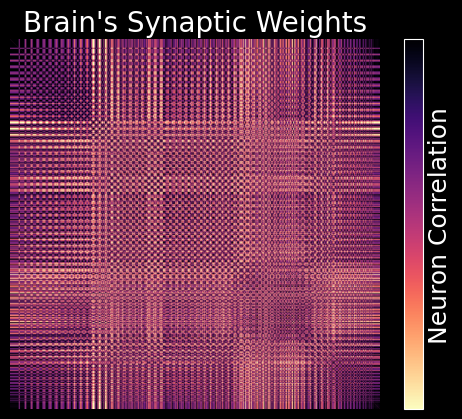

In [14]:
see_synapses(weights)